# 07 — Set→Pair Fusion

Pairwise DNN with frozen setwise context (mean hidden 32-d). All N² pairs.

**Input**: `models/setwise/best_model.pt` (frozen), features + glyph data
**Output**: `data/processed/models/set_pair_fusion/*`


In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = DATA_PROCESSED / "features"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
MODEL_DIR = DATA_PROCESSED / "models" / "set_pair_fusion"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
NUM_CLASSES = 52
FEATURE_DIM = 512
INPUT_DIM = FEATURE_DIM * 2 + NUM_CLASSES * 2  # 1128

D_MODEL = 32
NHEAD = 2
NUM_LAYERS = 1
FUSION_INPUT_DIM = INPUT_DIM + D_MODEL  # 1160

BATCH_SIZE = 64
LEARNING_RATE = 1e-4
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 20
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)
log.info("Root: %s", PROJECT_ROOT)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SETWISE_BEST_MODEL = DATA_PROCESSED / "models" / "setwise" / "best_model.pt"


2026-07-26 09:06:00,502 | INFO | Device: cuda
2026-07-26 09:06:00,503 | INFO | Root: C:\Users\angel\OneDrive\Desktop\Kern


In [2]:
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
feat_manifest = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_stems = [s for s in feat_manifest[feat_manifest["status"] == "ok"]["stem"] if s in set(catalog["stem"])]
unique_stems = sorted(ok_stems)
log.info("Fonts with features: %d", len(unique_stems))

features_cache = {}
pair_dist_lookup = {}
glyph_names_cache = {}

for stem in tqdm(unique_stems, desc="Loading"):
    fz = np.load(FEATURE_DIR / f"{stem}.npz")
    features_cache[stem] = fz["features"]
    gz = np.load(GLYPH_DIR / f"{stem}.npz")
    glyph_names_cache[stem] = list(gz["glyph_names"])
    left, right, dists = gz["pair_left"], gz["pair_right"], gz["pair_distances"]
    lookup = {}
    for i in range(len(left)):
        lookup[(int(left[i]), int(right[i]))] = float(dists[i])
    pair_dist_lookup[stem] = lookup

total_mb = sum(a.nbytes for a in features_cache.values()) / 1e6
log.info("Features loaded: %.0f MB", total_mb)

stem_family = {}
for _, row in catalog[catalog["stem"].isin(unique_stems)].iterrows():
    stem_family[row["stem"]] = row["family"]

stem_specs = []
for stem in unique_stems:
    N = len(glyph_names_cache[stem])
    family = stem_family.get(stem, "unknown")
    stem_specs.append((stem, family, N))

all_families = sorted(set(f for _, f, _ in stem_specs))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(all_families)

n = len(all_families)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_families = set(all_families[:n_train])
val_families = set(all_families[n_train:n_train + n_val])
test_families = set(all_families[n_train + n_val:])

train_specs = [s for s in stem_specs if s[1] in train_families]
val_specs = [s for s in stem_specs if s[1] in val_families]
test_specs = [s for s in stem_specs if s[1] in test_families]

train_pairs = sum(s[2] * s[2] for s in train_specs)
val_pairs = sum(s[2] * s[2] for s in val_specs)
test_pairs = sum(s[2] * s[2] for s in test_specs)
log.info("Families: %d train / %d val / %d test", len(train_families), len(val_families), len(test_families))
log.info("Pairs: %d train / %d val / %d test", train_pairs, val_pairs, test_pairs)

# Frozen setwise model: precompute mean hidden after norm
class SetwiseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(FEATURE_DIM * 2, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, batch_first=True,
            dim_feedforward=D_MODEL * 4, activation="relu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)
        self.norm = nn.LayerNorm(D_MODEL)
        self.output_proj = nn.Linear(D_MODEL, 1)

    def forward(self, x, mask=None):
        x = self.input_proj(x)
        x = self.transformer(x, src_key_padding_mask=mask)
        x = self.norm(x)
        return x

sw_model = SetwiseModel().to(DEVICE)
sw_model.load_state_dict(torch.load(SETWISE_BEST_MODEL, weights_only=True, map_location=DEVICE), strict=False)
sw_model.eval()
log.info("Frozen setwise model loaded")

global_ctx_cache = {}
for stem in tqdm(unique_stems, desc="Precomputing SW context"):
    feat = features_cache[stem]
    N = feat.shape[0]
    tokens = np.empty((N * N, FEATURE_DIM * 2), dtype=np.float32)
    idx = 0
    for i in range(N):
        fi = feat[i]
        for j in range(N):
            tokens[idx, :FEATURE_DIM] = fi
            tokens[idx, FEATURE_DIM:] = feat[j]
            idx += 1
    t = torch.from_numpy(tokens).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        hidden = sw_model(t, None)
    global_ctx_cache[stem] = hidden.mean(dim=1).squeeze(0).cpu()

del sw_model
if DEVICE == "cuda": torch.cuda.empty_cache()
log.info("Global context precomputed for %d fonts", len(global_ctx_cache))


2026-07-26 09:06:13,321 | INFO | Fonts with features: 7263


Loading:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-26 09:06:45,943 | INFO | Features loaded: 773 MB
2026-07-26 09:06:46,115 | INFO | Families: 1488 train / 186 val / 187 test
2026-07-26 09:06:46,115 | INFO | Pairs: 15569632 train / 1944176 val / 2125344 test
2026-07-26 09:06:47,573 | INFO | Frozen setwise model loaded


Precomputing SW context:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-26 09:07:44,201 | INFO | Global context precomputed for 7263 fonts


In [3]:
_char_to_idx = {c: i for i, c in enumerate(LATIN_52)}

class FusionPairwiseDataset(Dataset):
    def __init__(self, specs):
        self.stems = [s[0] for s in specs]
        self.Ns = [s[2] for s in specs]
        self._offsets = np.zeros(len(specs), dtype=np.int64)
        cum = 0
        for i, n in enumerate(self.Ns):
            self._offsets[i] = cum
            cum += n * n
        self._total = cum

    def __len__(self):
        return self._total

    def __getitem__(self, idx):
        stem_i = int(np.searchsorted(self._offsets, idx, side='right') - 1)
        stem = self.stems[stem_i]
        N = self.Ns[stem_i]
        local = idx - int(self._offsets[stem_i])
        li = local // N
        ri = local % N

        names = glyph_names_cache[stem]
        g1, g2 = names[li], names[ri]
        feat = features_cache[stem]
        f1 = torch.from_numpy(feat[li])
        f2 = torch.from_numpy(feat[ri])

        ci1 = _char_to_idx.get(g1)
        ci2 = _char_to_idx.get(g2)
        target = pair_dist_lookup[stem][(ci1, ci2)]

        oh1 = torch.zeros(NUM_CLASSES)
        oh2 = torch.zeros(NUM_CLASSES)
        if ci1 is not None: oh1[ci1] = 1.0
        if ci2 is not None: oh2[ci2] = 1.0

        ctx = global_ctx_cache[stem]
        x = torch.cat([f1, f2, oh1, oh2, ctx])
        return x, torch.tensor(target, dtype=torch.float32)

train_ds = FusionPairwiseDataset(train_specs)
val_ds = FusionPairwiseDataset(val_specs)
test_ds = FusionPairwiseDataset(test_specs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
log.info("DataLoaders ready — %d train pairs", len(train_ds))


2026-07-26 09:07:44,211 | INFO | DataLoaders ready — 15569632 train pairs


In [4]:
class PairwiseDNN(nn.Module):
    def __init__(self, input_dim=FUSION_INPUT_DIM, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = PairwiseDNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
log.info("Model parameters: %d", n_params)


2026-07-26 09:07:44,225 | INFO | Model parameters: 363265


In [5]:
CHECKPOINT_PATH = MODEL_DIR / "checkpoint.pt"
BEST_MODEL_PATH = MODEL_DIR / "best_model.pt"
HISTORY_PATH = MODEL_DIR / "training_history.csv"

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total = 0.0, 0
    desc = "Train" if is_train else "Eval"
    for x, y in tqdm(loader, desc=desc, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y)
        total += len(y)
    return total_loss / total

start_epoch = 1
history = []
best_val_loss = float("inf")
patience_counter = 0

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, weights_only=False, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt.get("history", [])
    log.info("Resumed from epoch %d", ckpt["epoch"])
else:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    log.info("Starting fresh. LR=%.0e, batch=%d", LEARNING_RATE, BATCH_SIZE)

criterion = nn.L1Loss()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader, model, criterion)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    log.info("Epoch %3d | train_loss=%.4f val_loss=%.4f", epoch, train_loss, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        log.info("  -> Saved best model")
    else:
        patience_counter += 1

    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(), "best_val_loss": best_val_loss,
        "patience_counter": patience_counter, "history": history}, CHECKPOINT_PATH)

    if patience_counter >= EARLY_STOP_PATIENCE:
        log.info("Early stopping at epoch %d", epoch)
        break

pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
log.info("Done.")

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()


2026-07-26 09:07:45,758 | INFO | Starting fresh. LR=1e-04, batch=64


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-26 09:34:53,050 | INFO | Epoch   1 | train_loss=4.4031 val_loss=4.4869
2026-07-26 09:34:53,058 | INFO |   -> Saved best model


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-27 13:46:38,793 | INFO | Epoch  64 | train_loss=2.2002 val_loss=3.6643


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-27 14:13:39,991 | INFO | Epoch  65 | train_loss=2.1941 val_loss=3.6433
2026-07-27 14:13:40,004 | INFO | Early stopping at epoch 65
2026-07-27 14:13:40,192 | INFO | Done.


In [7]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True, map_location=DEVICE))
model.eval()

all_preds, all_targets, all_stems = [], [], []
with torch.no_grad():
    for stem, _, N in tqdm(test_specs, desc="Testing per-font"):
        names = glyph_names_cache[stem]
        feat = features_cache[stem]
        ctx = global_ctx_cache[stem]
        for li in range(N):
            g1 = names[li]
            ci1 = _char_to_idx.get(g1)
            oh1 = torch.zeros(NUM_CLASSES)
            if ci1 is not None: oh1[ci1] = 1.0
            f1 = torch.from_numpy(feat[li])
            for ri in range(N):
                g2 = names[ri]
                ci2 = _char_to_idx.get(g2)
                oh2 = torch.zeros(NUM_CLASSES)
                if ci2 is not None: oh2[ci2] = 1.0
                f2 = torch.from_numpy(feat[ri])
                x = torch.cat([f1, f2, oh1, oh2, ctx]).unsqueeze(0).to(DEVICE)
                pred = model(x).item()
                target = pair_dist_lookup[stem][(ci1, ci2)]
                all_preds.append(pred)
                all_targets.append(target)
                all_stems.append(stem)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
test_mae = np.abs(all_preds - all_targets).mean()
log.info("Test MAE flat: %.4f px", test_mae)

test_font_mae = []
for stem_spec in test_specs:
    s = stem_spec[0]
    mask = np.array([s == st for st in all_stems])
    if mask.sum() > 0:
        mae_s = np.abs(all_preds[mask] - all_targets[mask]).mean()
        test_font_mae.append({"stem": s, "mae": mae_s})

df_font_mae = pd.DataFrame(test_font_mae)
df_font_mae.to_csv(MODEL_DIR / "test_font_mae.csv", index=False)
pd.DataFrame({"test_mae_flat": [test_mae]}).to_csv(MODEL_DIR / "test_mae_flat.csv", index=False)
log.info("Saved CSVs")


Testing per-font:   0%|          | 0/786 [00:00<?, ?it/s]

2026-07-27 15:21:35,797 | INFO | Test MAE flat: 4.0446 px
2026-07-27 15:23:43,440 | INFO | Saved CSVs


In [8]:
print("=" * 60)
print("SET->PAIR FUSION - RESULTS")
print("=" * 60)

hist = pd.read_csv(HISTORY_PATH)
sp_flat = pd.read_csv(MODEL_DIR / "test_mae_flat.csv")["test_mae_flat"].values[0]
print(f"\n  Epochs trained:   {len(hist)}")
print(f"  Best val MAE:     {hist['val_loss'].min():.4f} px")
print(f"  Test MAE flat:    {sp_flat:.4f} px")
print(f"\n  Per-font MAE:")
print(f"    mean:           {df_font_mae['mae'].mean():.4f} px")
print(f"    median:         {df_font_mae['mae'].median():.4f} px")
print(f"    std:            {df_font_mae['mae'].std():.4f} px")
print(f"    fonts < 7 px:   {(df_font_mae['mae'] < 7).sum()} / {len(df_font_mae)}")
print("\n" + "=" * 60)


SET->PAIR FUSION - RESULTS

  Epochs trained:   65
  Best val MAE:     3.6226 px
  Test MAE flat:    4.0446 px

  Per-font MAE:
    mean:           4.0446 px
    median:         3.2583 px
    std:            3.4829 px
    fonts < 7 px:   694 / 786



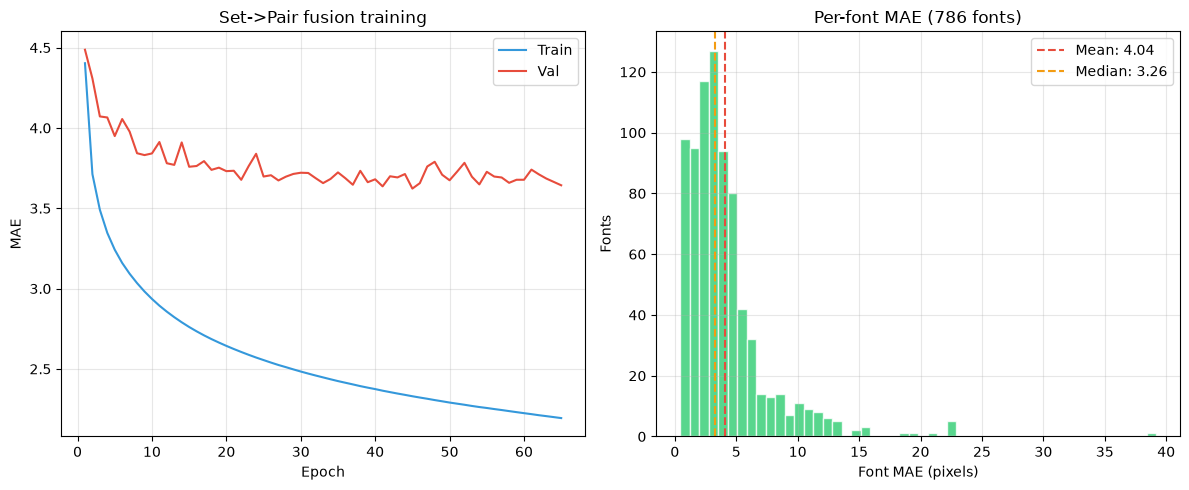

In [9]:
import matplotlib.pyplot as plt

hist = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(hist["epoch"], hist["train_loss"], label="Train", color="#3498db")
axes[0].plot(hist["epoch"], hist["val_loss"], label="Val", color="#e74c3c")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].set_title("Set->Pair fusion training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_font_mae["mae"], bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].axvline(df_font_mae["mae"].mean(), color="#e74c3c", linestyle="--", label=f"Mean: {df_font_mae['mae'].mean():.2f}")
axes[1].axvline(df_font_mae["mae"].median(), color="#f39c12", linestyle="--", label=f"Median: {df_font_mae['mae'].median():.2f}")
axes[1].set_xlabel("Font MAE (pixels)")
axes[1].set_ylabel("Fonts")
axes[1].set_title(f"Per-font MAE ({len(df_font_mae)} fonts)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
